Name | Surname | index
-|-|-
Natan | Jabłoński | 155621

# Description
This notebooks contains all data preprocessing pipelines and some utilities, which other more model oriented notebooks will use:
* importing the dataset
* showcasing images
* augumentation
* filters

# Module imports

In [1]:
import inspect
import os 
from veinClassifier.dataset import EyeDataset
from veinClassifier.complexFilter import complexInputFilter, complexOutputFilter
from matplotlib import pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split
from IPython.display import Markdown, display
from tqdm import tqdm

# Basic data import
A pytorch dataset object was designed to both allow access to the dataset and provide compatibility with the pytorch framework

In [2]:
display(Markdown(f"""
## EyeDataset
```python
{inspect.getsource(EyeDataset)}
```
"""))


## EyeDataset
```python
class EyeDataset(Dataset):
    def __init__(self, img_dir, mask_dir, imgFilter=None, rawImg=False, noGPU=False, transpose=True):
        self.img_dir = img_dir
        self.mask_dir = mask_dir
        self.imgFiles = sorted(os.listdir(img_dir))
        self.maskFiles = sorted(os.listdir(mask_dir))
        self.imgFilter = imgFilter
        self.rawImg = rawImg
        self.noGPU = noGPU
        self.transpose = transpose

    def __len__(self):
        return len(self.imgFiles)

    def __getitem__(self, idx):
        imgFile = self.imgFiles[idx]
        maskFile = self.maskFiles[idx]

        img = cv2.imread(os.path.join(self.img_dir, imgFile))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        segm = cv2.imread(os.path.join(self.mask_dir, maskFile), cv2.IMREAD_GRAYSCALE)
        
        if self.imgFilter is not None:
            img = self.imgFilter(img)
        elif not self.rawImg:
            img = np.array(img) / 255.0
        
        segm = np.array(segm) / 255.0
        
        if self.transpose:
            img = np.transpose(img, (2, 0, 1))

        segm = (segm > 0.5).astype(np.float32)

        if self.noGPU:
            return img, segm

        x_img = torch.tensor(img).float()
        y_segm = torch.tensor(segm).unsqueeze(0).float()

        return x_img, y_segm

```


In [18]:
project_root = Path.cwd().parent

dataset = EyeDataset(project_root / "data/healthy/", project_root / "data/healthy_manualsegm")

img, segm = dataset[0]

## Eye fundus image

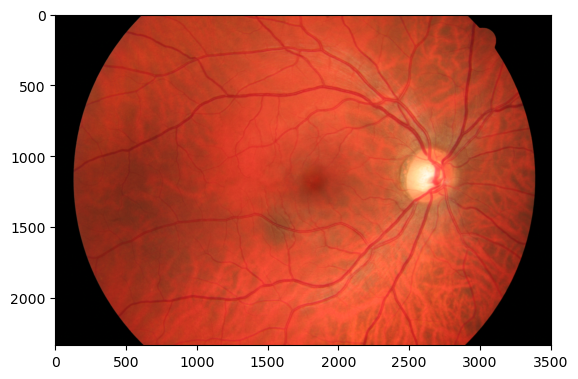

In [19]:
plt.imshow(img.permute(1,2,0))
plt.show()

## Manual segmentation image

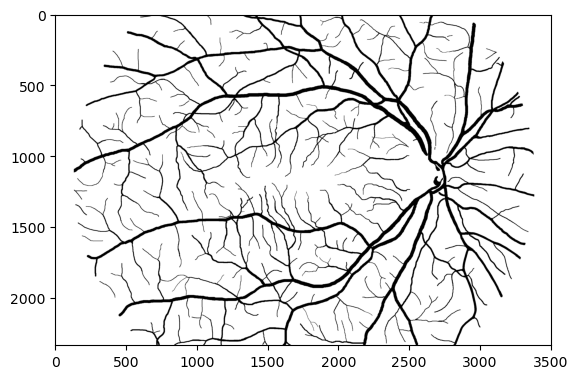

In [20]:
plt.imshow(~(segm.squeeze() > 0.5), cmap="gray")
plt.show() #AUC ROC

# Segmentation class imbalance

In [16]:
import numpy as np
from tqdm import tqdm

dataset_test = EyeDataset(
    project_root / "data/healthy/",
    project_root / "data/healthy_manualsegm",
    noGPU=True,
    transpose=False,
    imgFilter=None
)

total_zeros = 0
total_ones = 0

for i in tqdm(range(len(dataset_test))):
    _, mask = dataset_test[i]

    # ensure binary
    mask = (mask > 0.5).astype(np.uint8)

    total_zeros += np.sum(mask == 0)
    total_ones += np.sum(mask == 1)

print("Total background (0):", total_zeros)
print("Total vessel (1):", total_ones)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00,  8.50it/s]

Total background (0): 111350202
Total vessel (1): 11429958


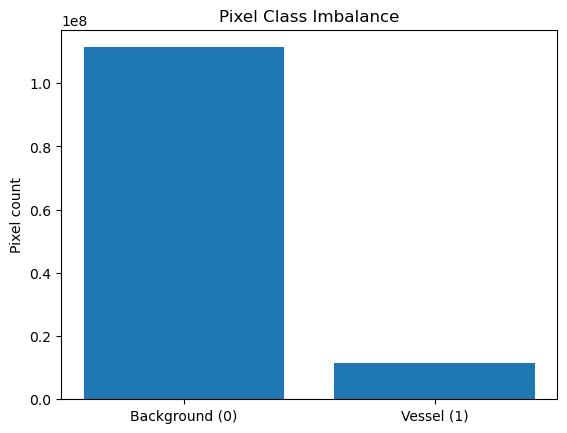

In [17]:
import matplotlib.pyplot as plt

labels = ["Background (0)", "Vessel (1)"]
values = [total_zeros, total_ones]

plt.figure()
plt.bar(labels, values)
plt.title("Pixel Class Imbalance")
plt.ylabel("Pixel count")
plt.show()

# Applying filters

In [6]:
display(Markdown(f"""
## Input filter (image filter)
Filters can be applied at dataset level

```python
{inspect.getsource(complexInputFilter)}
```
"""))


## Input filter (image filter)
Filters can be applied at dataset level

```python
def complexInputFilter(image):
    # green chanel
    green = image[:, :, 1]
    green = 255 - green

    # CLAHE
    enhanced = exposure.equalize_adapthist(green)

    # Gaussian smoothing
    smooth = gaussian(enhanced, sigma=1)

    # FRANGI
    vessel = frangi(smooth, sigmas=range(1, 5), black_ridges=True)

    vessel = (vessel - vessel.min()) / (vessel.max() - vessel.min() + 1e-8)

    # overlay instead of replace
    rgb = image.astype(np.float32) / 255.0

    rgb_overlay = rgb.copy()
    rgb_overlay[:,:,1] = np.maximum(rgb[:,:,1], vessel)  # enhance green channel
    rgb_overlay[:,:,0] = rgb[:,:,0] * 0.3 
    rgb_overlay[:,:,2] = rgb[:,:,2] * 0.7 

    return rgb_overlay

```


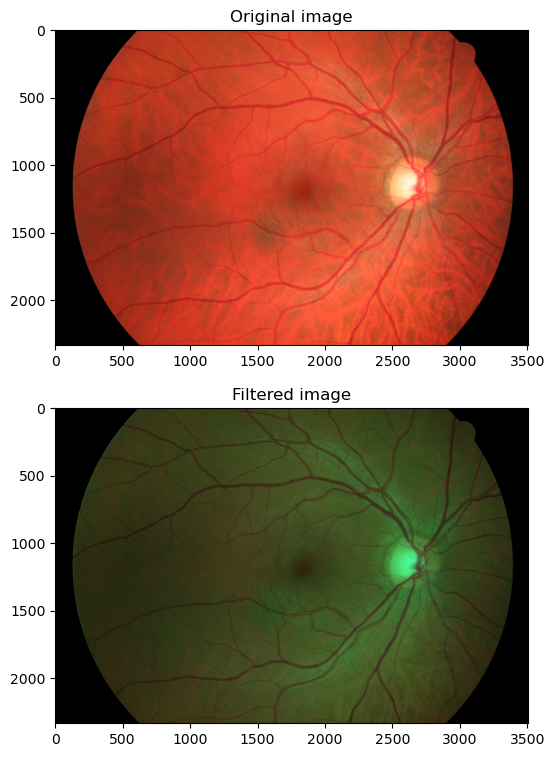

In [7]:
f_dataset = EyeDataset(project_root / "data/healthy/", project_root / "data/healthy_manualsegm", imgFilter=complexInputFilter)

f_img, f_segm = f_dataset[0]

fig, axes = plt.subplots(2, figsize=(18, 9))

axes[0].imshow(img.permute(1,2,0))
axes[0].set_title(f"Original image")
axes[1].imshow(f_img.permute(1,2,0))
axes[1].set_title(f"Filtered image")

plt.show()


In [8]:
display(Markdown(f"""
## Output filter (segmentation filter)
Denoises output segmentation, allowing for slightly better output.

```python
{inspect.getsource(complexOutputFilter)}
```
"""))


## Output filter (segmentation filter)
Denoises output segmentation, allowing for slightly better output.

```python
def complexOutputFilter(segm, size=50):
    mask_bool = segm.astype(bool)

    cleaned = remove_small_objects(mask_bool, max_size = size)

    cleaned = remove_small_holes(cleaned, max_size = size)

    cleaned = cleaned.astype(np.uint8)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    cleaned = cv2.morphologyEx(cleaned, cv2.MORPH_CLOSE, kernel)

    return cleaned

```


# Data augumentation

## Filter

In [9]:
from pathlib import Path
from PIL import Image

input_image_dir = project_root / "data/healthy/"
input_segm_dir = project_root / "data/healthy_manualsegm/"
output_dir = project_root / "data/healthy_filtered"
output_dir.mkdir(parents=True, exist_ok=True)

dataset = EyeDataset(
    input_image_dir,
    input_segm_dir,
    imgFilter=complexInputFilter,
    noGPU=True,
    transpose=False
)

filenames = sorted(os.listdir(input_image_dir))

for idx, filename in zip(range(len(dataset)), filenames):
    img, _ = dataset[idx]

    img_uint8 = (img * 255).clip(0, 255).astype("uint8")

    out_path = output_dir / filename

    Image.fromarray(img_uint8).save(out_path, quality=95)

    print(f"Saved {out_path}")

Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/01_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/02_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/03_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/04_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/05_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/06_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/07_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/08_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/09_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/10_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/11_h.jpg
Saved /home/teuthid/Documents/python/veinClassifier/data/healthy_filtered/12_h.jpg
Save

## Augumenting original and filtered dataset

In [21]:
from pathlib import Path
from PIL import Image
import numpy as np

dataset = EyeDataset(
    project_root / "data/healthy",
    project_root / "data/healthy_manualsegm",
    noGPU=True,
    transpose=False
)

dataset_filtered = EyeDataset(
    project_root / "data/healthy_filtered",
    project_root / "data/healthy_manualsegm",
    noGPU=True,
    transpose=False
)

img_out = project_root / "data/healthy_aug"
filtered_img_out = project_root / "data/healthy_aug_filtered"
mask_out = project_root / "data/healthy_aug_manualsegm"

img_out.mkdir(parents=True, exist_ok=True)
mask_out.mkdir(parents=True, exist_ok=True)

augmentations = [
    ("orig", lambda x: x, 0),
    ("hflip", np.fliplr, 1000),
    ("vflip", np.flipud, 2000),
    ("hvflip", lambda x: np.flipud(np.fliplr(x)), 3000),
]

for aug_name, aug_fn, offset in augmentations:

    for idx in range(len(dataset)):
        img, segm = dataset[idx]
        img_filtered, _ = dataset_filtered[idx]

        img_aug = aug_fn(img)
        img_aug_filtered = aug_fn(img_filtered)
        segm_aug = aug_fn(segm)

        filename = f"{offset + idx:04d}_{aug_name}.jpg"
        mask_filename = f"{offset + idx:04d}_{aug_name}.png"

        Image.fromarray(
            (img_aug * 255).astype(np.uint8)
        ).save(img_out / filename)

        Image.fromarray(
            (img_aug_filtered * 255).astype(np.uint8)
        ).save(filtered_img_out / filename)

        Image.fromarray(
            (segm_aug * 255).astype(np.uint8)
        ).save(mask_out / mask_filename)

        print(filename)

0000_orig.jpg
0001_orig.jpg
0002_orig.jpg
0003_orig.jpg
0004_orig.jpg
0005_orig.jpg
0006_orig.jpg
0007_orig.jpg
0008_orig.jpg
0009_orig.jpg
0010_orig.jpg
0011_orig.jpg
0012_orig.jpg
0013_orig.jpg
0014_orig.jpg
1000_hflip.jpg
1001_hflip.jpg
1002_hflip.jpg
1003_hflip.jpg
1004_hflip.jpg
1005_hflip.jpg
1006_hflip.jpg
1007_hflip.jpg
1008_hflip.jpg
1009_hflip.jpg
1010_hflip.jpg
1011_hflip.jpg
1012_hflip.jpg
1013_hflip.jpg
1014_hflip.jpg
2000_vflip.jpg
2001_vflip.jpg
2002_vflip.jpg
2003_vflip.jpg
2004_vflip.jpg
2005_vflip.jpg
2006_vflip.jpg
2007_vflip.jpg
2008_vflip.jpg
2009_vflip.jpg
2010_vflip.jpg
2011_vflip.jpg
2012_vflip.jpg
2013_vflip.jpg
2014_vflip.jpg
3000_hvflip.jpg
3001_hvflip.jpg
3002_hvflip.jpg
3003_hvflip.jpg
3004_hvflip.jpg
3005_hvflip.jpg
3006_hvflip.jpg
3007_hvflip.jpg
3008_hvflip.jpg
3009_hvflip.jpg
3010_hvflip.jpg
3011_hvflip.jpg
3012_hvflip.jpg
3013_hvflip.jpg
3014_hvflip.jpg


## Preprocessing

# Splitiing the data into train, validation and test sets

In [10]:
from torch.utils.data import DataLoader
import torch
from torch.utils.data import random_split


train_size = int(0.6 * len(dataset))
val_size = int(0.2 * len(dataset))
test_size = int(0.2 * len(dataset))

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=1, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_size=1, shuffle=False)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')